# Bird Role-SQL Generation Workflow

## 1. Environment preparation

In [1]:
# Enable autoreload and configure baseline logging
%load_ext autoreload
%autoreload 2

import json
import os
import logging
import sys
import subprocess
import matplotlib.pyplot as plt

from datetime import datetime
from wordcloud import WordCloud
from pathlib import Path
from typing import Optional

import pandas as pd

# Reset existing handlers to prevent duplicate logs across reruns.
for existing_handler in logging.root.handlers[:]:
    logging.root.removeHandler(existing_handler)

console_handler = logging.StreamHandler()
console_handler.setLevel(logging.INFO)
console_formatter = logging.Formatter("[%(levelname)s] %(message)s")
console_handler.setFormatter(console_formatter)

logging.basicConfig(level=logging.INFO, handlers=[console_handler])

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_colwidth", 120)

logger = logging.getLogger("bird_notebook")
logger.info("Environment initialized; console logging limited to essentials.")

[INFO] Environment initialized; console logging limited to essentials.


## 2. Locate project paths and validate inputs

In [2]:
# Resolve project root and validate required directories/files
project_root = Path.cwd().resolve()
marker = "requirements.txt"
if not (project_root / marker).exists():
    for candidate in project_root.parents:
        if (candidate / marker).exists():
            project_root = candidate
            break

if not (project_root / marker).exists():
    raise RuntimeError("Unable to locate a project root containing requirements.txt. Verify the notebook working directory.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.processors.bird_describer import BirdDatabaseDescriber
from src.processors.bird_role_processor import BirdRoleProcessor
from src.processors.bird_role_sql_generator import BirdRoleSQLGenerator
from src.role_parser.generator import ParallelRoleGenerator

outputs_dir = project_root / "outputs"
logs_dir = project_root / "logs"
logs_dir.mkdir(parents=True, exist_ok=True)
bird_dev_dir = project_root / "data" / "Bird" / "dev_20240627"
bird_databases_dir = bird_dev_dir / "dev_databases"
bird_source_file = bird_dev_dir / "dev.json"

def locate_latest(pattern: str):
    candidates = sorted(outputs_dir.glob(pattern), key=lambda p: p.stat().st_mtime if p.exists() else 0)
    return candidates[-1] if candidates else None

role_assignments_path = locate_latest("role_assignments_bird_dev_*.json")
existing_dataset_path = locate_latest("role_sql_dataset_bird_dev_*.json")

# Attach a file handler capturing detailed logs for later review.
notebook_log_path = logs_dir / f"bird_role_generation_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
if not any(isinstance(h, logging.FileHandler) and getattr(h, "baseFilename", "") == str(notebook_log_path) for h in logger.handlers):
    file_handler = logging.FileHandler(notebook_log_path, mode="w", encoding="utf-8")
    file_handler.setLevel(logging.DEBUG)
    file_formatter = logging.Formatter("[%(asctime)s] %(levelname)s %(name)s: %(message)s")
    file_handler.setFormatter(file_formatter)
    logger.addHandler(file_handler)
    logger.debug("File handler attached for detailed logging.")

if role_assignments_path:
    logger.info("Latest saved role assignments (reference only): %s", role_assignments_path)
else:
    logger.info("No prior role assignments detected; this run will create a fresh file.")

if existing_dataset_path:
    logger.info("Latest saved dataset (reference only): %s", existing_dataset_path)
else:
    logger.info("No prior Bird Role-SQL dataset detected; this run will create a fresh file.")

checks = {
    "project_root": project_root,
    "outputs_dir": outputs_dir,
    "bird_databases_dir": bird_databases_dir,
    "bird_source_file": bird_source_file,
    "role_assignments_path": role_assignments_path if role_assignments_path else Path("<fresh_run_expected>"),
    "existing_dataset_path": existing_dataset_path if existing_dataset_path else Path("<fresh_run_expected>"),
}

status_rows = [
    {"Name": name, "Exists": (path.exists() if isinstance(path, Path) else path and Path(path).exists()), "Absolute Path": str(path)}
    for name, path in checks.items()
]

status_df = pd.DataFrame(status_rows)
display(status_df)

missing_items = status_df.loc[~status_df["Exists"], "Name"].tolist()
if missing_items:
    logger.warning("Some optional resources are missing: %s", missing_items)
logger.info("Path validation completed successfully.")
print(f"Detailed log will be written to: {notebook_log_path}")

/home/feiy/anaconda3/envs/llm4db/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[INFO] Latest saved role assignments (reference only): /home/feiy/Role-SQL-benchmark/outputs/role_assignments_bird_dev_20250929_210027.json
[INFO] Latest saved dataset (reference only): /home/feiy/Role-SQL-benchmark/outputs/role_sql_dataset_bird_dev_20250929_210522.json
[INFO] Latest saved dataset (reference only): /home/feiy/Role-SQL-benchmark/outputs/role_sql_dataset_bird_dev_20250929_210522.json


,Name,Exists,Absolute Path
0,project_root,True,/home/feiy/Role-SQL-benchmark
1,outputs_dir,True,/home/feiy/Role-SQL-benchmark/outputs
2,bird_databases_dir,True,/home/feiy/Role-SQL-benchmark/data/Bird/dev_20240627/dev_databases
3,bird_source_file,True,/home/feiy/Role-SQL-benchmark/data/Bird/dev_20240627/dev.json
4,role_assignments_path,True,/home/feiy/Role-SQL-benchmark/outputs/role_assignments_bird_dev_20250929_210027.json
5,existing_dataset_path,True,/home/feiy/Role-SQL-benchmark/outputs/role_sql_dataset_bird_dev_20250929_210522.json


[INFO] Path validation completed successfully.


Detailed log will be written to: /home/feiy/Role-SQL-benchmark/logs/bird_role_generation_20250929_210717.log


## 3. Inspect Bird assets

In [3]:
describer = BirdDatabaseDescriber(project_root)
bird_database_dirs = sorted(
    [path for path in bird_databases_dir.iterdir() if path.is_dir() and not path.name.startswith(".")]
 )
total_dbs = len(bird_database_dirs)
print(f"Found {total_dbs} Bird dev databases")
for db_path in bird_database_dirs[:5]:
    print(f" - {db_path.name}")

db_summaries = []
table_level_rows = []
for db_path in bird_database_dirs:
    db_info = describer.read_database_descriptions(db_path)
    if not db_info:
        logger.warning("Schema info missing for %s", db_path.name)
        continue
    db_summaries.append({
        "db_id": db_info.db_name,
        "tables": db_info.total_tables,
        "columns": db_info.total_columns,
        "avg_columns_per_table": db_info.total_columns / db_info.total_tables if db_info.total_tables else 0,
    })
    for table in db_info.tables:
        table_level_rows.append({
            "db_id": db_info.db_name,
            "table": table.table_name,
            "column_count": table.column_count,
        })

summary_df = pd.DataFrame(db_summaries) if db_summaries else pd.DataFrame(columns=["db_id","tables","columns","avg_columns_per_table"])
table_stats_df = pd.DataFrame(table_level_rows) if table_level_rows else pd.DataFrame(columns=["db_id","table","column_count"])

if not summary_df.empty:
    overall_metrics = pd.Series({
        "Avg tables per database": round(summary_df["tables"].mean(), 2),
        "Avg columns per database": round(summary_df["columns"].mean(), 2),
        "Avg columns per table": round(summary_df["avg_columns_per_table"].mean(), 2),
    })
    display(summary_df.sort_values("tables", ascending=False).head(10))
    display(overall_metrics.to_frame(name="value"))
else:
    print("No database summaries available; check schema descriptions.")

if bird_database_dirs:
    sample_db_path = bird_database_dirs[0]
    sample_info = describer.read_database_descriptions(sample_db_path)
    if sample_info:
        preview = describer.generate_schema_description(sample_info, format_type="summary")
        print(f"\nPreview summary for {sample_db_path.name}:\n")
        print("\n".join(preview.splitlines()[:40]))
    else:
        print(f"No structured description available for {sample_db_path.name}.")
else:
    raise RuntimeError("No Bird databases found under data/Bird/dev_20240627/dev_databases.")

Found 11 Bird dev databases
 - california_schools
 - card_games
 - codebase_community
 - debit_card_specializing
 - european_football_2


,db_id,tables,columns,avg_columns_per_table
6,formula_1,13,94,7.230769
8,superhero,10,31,3.100000
2,codebase_community,8,71,8.875000
7,student_club,8,48,6.000000
5,financial,8,55,6.875000
4,european_football_2,7,199,28.428571
1,card_games,6,115,19.166667
3,debit_card_specializing,5,21,4.200000
10,toxicology,4,11,2.750000
0,california_schools,3,89,29.666667


,value
Avg tables per database,6.82
Avg columns per database,72.55
Avg columns per table,12.51



Preview summary for california_schools:

Database: california_schools
Tables: 3, Columns: 89

Table: frpm (29 columns)
  Key columns: CDSCode (integer), Academic Year (integer), County Code (integer), District Code (integer), School Code (integer)
  ... and 24 more columns

Table: satscores (11 columns)
  Key columns: cds (text), rtype (text), sname (text), dname (text), cname (text)
  ... and 6 more columns

Table: schools (49 columns)
  Key columns: CDSCode (text), NCESDist (text), NCESSchool (text), StatusType (text), County (text)
  ... and 44 more columns


## 4. Configure role generator

In [4]:
# Control how many databases trigger real LLM role generation
env_limit = os.environ.get("BIRD_SAMPLE_DATABASE_LIMIT")
if env_limit is None or env_limit.strip() == "":
    SAMPLE_DATABASE_LIMIT = None  # default to full Bird run
else:
    limit_token = env_limit.strip().lower()
    if limit_token in {"none", "all"}:
        SAMPLE_DATABASE_LIMIT = None
    else:
        try:
            SAMPLE_DATABASE_LIMIT = int(env_limit)
        except ValueError:
            logger.warning("Invalid BIRD_SAMPLE_DATABASE_LIMIT=%s; defaulting to full run.", env_limit)
            SAMPLE_DATABASE_LIMIT = None

total_databases = len(bird_database_dirs)

if SAMPLE_DATABASE_LIMIT is None:
    print(f"Role generation will process all {total_databases} database(s).")
elif isinstance(SAMPLE_DATABASE_LIMIT, int) and SAMPLE_DATABASE_LIMIT > 0:
    print(f"Role generation will process the first {min(SAMPLE_DATABASE_LIMIT, total_databases)} database(s).")
else:
    print("Role generation is currently skipped; set BIRD_SAMPLE_DATABASE_LIMIT to a positive integer or 'None' to trigger LLM calls.")

Role generation will process all 11 database(s).


### Credential and worker configuration

（在运行前确保设置好模型名称与 API Key，可通过环境变量 `BIRD_ROLE_MODEL`、`BIRD_ROLE_API_KEY` 或通用的 `DEEPSEEK_API_KEY`、`OPENAI_API_KEY` 等变量。）

In [5]:
model_name = os.environ.get("BIRD_ROLE_MODEL", "deepseek-chat")
api_key = (
    os.environ.get("BIRD_ROLE_API_KEY")
    or os.environ.get("DEEPSEEK_API_KEY")
    or os.environ.get("OPENAI_API_KEY")
    or os.environ.get("AZURE_OPENAI_API_KEY")
)
workers = int(os.environ.get("BIRD_ROLE_WORKERS", "8"))

if api_key:
    role_generator = ParallelRoleGenerator(model=model_name, api_key=api_key, n_workers=workers)
    role_processor = BirdRoleProcessor(generator=role_generator, describer=describer)
    print(f"Configured role generator with model={model_name}, workers={workers}")
else:
    role_generator = None
    role_processor = None
    print("API key not provided. Set BIRD_ROLE_API_KEY or another supported key before triggering role generation.")

Configured role generator with model=deepseek-chat, workers=8


## 5. Run role assignment

In [6]:
role_results: Optional[dict] = None
should_run = SAMPLE_DATABASE_LIMIT is None or (isinstance(SAMPLE_DATABASE_LIMIT, int) and SAMPLE_DATABASE_LIMIT > 0)

if should_run:
    if role_processor is None:
        raise RuntimeError("Role processor is not initialized. Provide an API key and rerun the configuration cell.")
    if SAMPLE_DATABASE_LIMIT is None:
        target_databases = bird_database_dirs
    else:
        target_databases = bird_database_dirs[:SAMPLE_DATABASE_LIMIT]
    if not target_databases:
        raise RuntimeError("No databases selected for role generation.")
    batch_size = min(len(target_databases), workers) if target_databases else workers
    run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    role_results = role_processor.process_bird_databases_batch(
        target_databases,
        batch_size=batch_size or 1,
        run_timestamp=run_timestamp,
    )
    print(json.dumps(role_results.get("metadata", {}), indent=2))
else:
    print("Role generation skipped because BIRD_SAMPLE_DATABASE_LIMIT=0. Set it to a positive integer or 'None' to trigger LLM calls.")
    logger.warning("Skipping role generation: BIRD_SAMPLE_DATABASE_LIMIT=0. No new role assignments will be produced in this run.")
    role_results = None

[INFO] Found 11 valid Bird databases for processing
[INFO] Valid databases: ['california_schools', 'card_games', 'codebase_community', 'debit_card_specializing', 'european_football_2', 'financial', 'formula_1', 'student_club', 'superhero', 'thrombosis_prediction', 'toxicology']
[INFO] 
Processing Bird Batch 1/2
[INFO] Databases: ['california_schools', 'card_games', 'codebase_community', 'debit_card_specializing', 'european_football_2', 'financial', 'formula_1', 'student_club']
[INFO] Processing 8 databases (0 skipped)
[INFO] Starting parallel API calls with 8 workers
[INFO] Valid databases: ['california_schools', 'card_games', 'codebase_community', 'debit_card_specializing', 'european_football_2', 'financial', 'formula_1', 'student_club', 'superhero', 'thrombosis_prediction', 'toxicology']
[INFO] 
Processing Bird Batch 1/2
[INFO] Databases: ['california_schools', 'card_games', 'codebase_community', 'debit_card_specializing', 'european_football_2', 'financial', 'formula_1', 'student_clu

Total queries: 8, start collecting...


Processing Items:   0%|          | 0/8 [00:00<?, ?it/s][INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
[INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
[INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
[INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
[INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
[INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
[INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
[INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
[INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
[INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
[INFO] HTTP Request: POST https://api.deepseek.com/v1/c

Total queries: 3, start collecting...


Processing Items:   0%|          | 0/3 [00:00<?, ?it/s][INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
[INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
[INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
[INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
[INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
[INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
Processing Items: 100%|██████████| 3/3 [00:08<00:00,  2.96s/it]
[INFO] Summary Statistics: Total API Calls: 3, Total Prompt Tokens: 4192, Total Completion Tokens: 433, Total Cached Tokens: 4032, Overall Cache Hit Rate: 96.2%
[INFO] Generated 4 roles for superhero - Cached Tokens: 1216; Uncached tokens: 55; Hit rates: 95.7%
[INFO] Generated 5 roles for thrombosis_prediction - Cached Tokens: 1984; Uncached tok

{
  "timestamp": "20250929_210717",
  "total_databases": 11,
  "processed_databases": 11,
  "total_roles_generated": 50,
  "batch_size": 8,
  "dataset_type": "bird_dev"
}


## 6. Persist role assignments

（如已生成角色结果，可写入 `outputs/` 目录以便后续复用。）

In [7]:
assignments_path: Optional[Path] = None
if role_results and role_results.get("assignments"):
    outputs_dir.mkdir(parents=True, exist_ok=True)
    timestamp = role_results.get("metadata", {}).get("timestamp") or datetime.now().strftime("%Y%m%d_%H%M%S")
    if role_processor is not None:
        assignments_path = role_processor.save_role_assignments(role_results, outputs_dir, filename_suffix=timestamp)
    else:
        assignments_path = outputs_dir / f"role_assignments_{timestamp}_bird_dev.json"
        with assignments_path.open("w", encoding="utf-8") as f:
            json.dump(role_results, f, ensure_ascii=False, indent=2)
        logger.info("Saved assignments using direct JSON write: %s", assignments_path)
    print(f"Assignments saved to {assignments_path}")
else:
    print("No assignments available to save yet.")

[INFO] Bird role assignments saved to: /home/feiy/Role-SQL-benchmark/outputs/role_assignments_bird_dev_20250929_210717.json
[INFO] File size: 11,269 bytes
[INFO] File size: 11,269 bytes


Assignments saved to /home/feiy/Role-SQL-benchmark/outputs/role_assignments_bird_dev_20250929_210717.json


In [8]:
from configs.prompts import INSTRUCTION_PROMPT, INPUT_PROMPT

processed_bird_data = []
missing_schema_count = 0
bird_dev_records: list[dict] = []

if not bird_source_file.exists():
    raise FileNotFoundError(f"Bird dev source file missing: {bird_source_file}")

with bird_source_file.open("r", encoding="utf-8") as f:
    bird_dev_records = json.load(f)

logger.info("Processing Bird dev.json to create in-memory instructions...")
logger.info("Total examples in dev.json: %s", f"{len(bird_dev_records):,}")

for item in bird_dev_records:
    db_id = item.get("db_id")
    question = item.get("question")
    sql = item.get("SQL")
    difficulty = item.get("difficulty")

    if not db_id or question is None or sql is None:
        logger.warning("Skipping entry with missing core fields: %s", item)
        continue

    db_path = bird_databases_dir / db_id
    schema_file = db_path / f"{db_id}_schema_detailed.txt"

    if not schema_file.exists():
        logger.warning("Schema file not found for database: %s", db_id)
        missing_schema_count += 1
        continue

    with schema_file.open("r", encoding="utf-8") as schema_fp:
        schema_lines = [line.rstrip("\n") for line in schema_fp]

    schema_desc = [line for line in schema_lines if line.strip() and not line.startswith("#")]
    schema_text = "\n".join(schema_desc)

    if not schema_text:
        logger.warning("Empty schema description for database: %s", db_id)
        missing_schema_count += 1
        continue

    instruction = INSTRUCTION_PROMPT.format(schema_text)
    input_text = question

    processed_entry = {
        "db_id": db_id,
        "instruction": instruction,
        "input": input_text,
        "output": sql,
    }

    if difficulty is not None:
        processed_entry["difficulty"] = difficulty

    processed_bird_data.append(processed_entry)

logger.info(
    "Bird dev data processing completed: %s processed, %s missing schemas.",
    f"{len(processed_bird_data):,}",
    missing_schema_count,
)
print(
    f"Processed Bird dev records: {len(processed_bird_data)}; schemas missing: {missing_schema_count}"
)

[INFO] Processing Bird dev.json to create in-memory instructions...
[INFO] Total examples in dev.json: 1,534
[INFO] Total examples in dev.json: 1,534
[INFO] Bird dev data processing completed: 1,534 processed, 0 missing schemas.
[INFO] Bird dev data processing completed: 1,534 processed, 0 missing schemas.


Processed Bird dev records: 1534; schemas missing: 0


## 7. Generate Bird Role-SQL dataset

In [9]:
dataset_output = None
role_sql_generator = BirdRoleSQLGenerator(project_root)
role_assignments_file = assignments_path

if not processed_bird_data:
    raise RuntimeError("Processed Bird dev dataset is empty. Verify schema files and prompts before generating Role-SQL dataset.")

if role_assignments_file is None:
    raise RuntimeError("Role assignments are missing. Run the previous cell to generate and save fresh assignments before building the dataset.")

if not role_assignments_file.exists():
    raise FileNotFoundError(f"Role assignment file not found on disk: {role_assignments_file}")

logger.info("Loaded %d processed Bird dev records for dataset synthesis.", len(processed_bird_data))
logger.info("Using role assignments file: %s", role_assignments_file)

dataset_output = role_sql_generator.generate_bird_role_sql_dataset(
    role_file_path=str(role_assignments_file),
    data_source="dev",
    bird_data=processed_bird_data,
)

if not dataset_output:
    raise RuntimeError("Dataset generation returned no rows. Check the role assignments and Bird source data.")

logger.info("Generated %d role-conditioned examples from %s", len(dataset_output), role_assignments_file)
print(f"Generated {len(dataset_output)} role-conditioned examples.")

preview_columns = ["db_id", "instruction", "role", "tables", "input", "output", "difficulty", "metadata"]
preview_df = pd.DataFrame(dataset_output[:8])[preview_columns]
display(preview_df)

[INFO] Loaded 1534 processed Bird dev records for dataset synthesis.
[INFO] Using role assignments file: /home/feiy/Role-SQL-benchmark/outputs/role_assignments_bird_dev_20250929_210717.json
[INFO] Using role assignments file: /home/feiy/Role-SQL-benchmark/outputs/role_assignments_bird_dev_20250929_210717.json
[INFO] Loaded difficulty entries for 1533 Bird questions (dev)
[INFO] Loaded difficulty entries for 1533 Bird questions (dev)
[INFO] Bird dataset generation completed for dev data:
[INFO] - Databases processed: 11
[INFO] - Databases skipped (no roles): 0
[INFO] - Total examples generated: 7069
[INFO] - Queries allowed: 3857
[INFO] - Queries denied: 3212
[INFO] - Denial rate: 45.44%
[INFO] Bird dataset generation completed for dev data:
[INFO] - Databases processed: 11
[INFO] - Databases skipped (no roles): 0
[INFO] - Total examples generated: 7069
[INFO] - Queries allowed: 3857
[INFO] - Queries denied: 3212
[INFO] - Denial rate: 45.44%
[INFO] Generated 7069 role-conditioned exampl

Generated 7069 role-conditioned examples.


,db_id,instruction,role,tables,input,output,difficulty,metadata
0,california_schools,"I want you to act as a SQL terminal in front of an example database, you need only to return the sql command to me.B...",SystemManager,"frpm,satscores,schools",What is the highest eligible free rate for K-12 students in the schools in Alameda County?,SELECT `Free Meal Count (K-12)` / `Enrollment (K-12)` FROM frpm WHERE `County Name` = 'Alameda' ORDER BY (CAST(`Free...,simple,{'gold_sql': 'SELECT `Free Meal Count (K-12)` / `Enrollment (K-12)` FROM frpm WHERE `County Name` = 'Alameda' ORDER ...
1,california_schools,"I want you to act as a SQL terminal in front of an example database, you need only to return the sql command to me.B...",EducationAnalyst,"satscores,schools",What is the highest eligible free rate for K-12 students in the schools in Alameda County?,"Sorry, I cannot answer.",simple,{'gold_sql': 'SELECT `Free Meal Count (K-12)` / `Enrollment (K-12)` FROM frpm WHERE `County Name` = 'Alameda' ORDER ...
2,california_schools,"I want you to act as a SQL terminal in front of an example database, you need only to return the sql command to me.B...",ProgramCoordinator,"frpm,schools",What is the highest eligible free rate for K-12 students in the schools in Alameda County?,SELECT `Free Meal Count (K-12)` / `Enrollment (K-12)` FROM frpm WHERE `County Name` = 'Alameda' ORDER BY (CAST(`Free...,simple,{'gold_sql': 'SELECT `Free Meal Count (K-12)` / `Enrollment (K-12)` FROM frpm WHERE `County Name` = 'Alameda' ORDER ...
3,california_schools,"I want you to act as a SQL terminal in front of an example database, you need only to return the sql command to me.B...",SchoolRegistrar,schools,What is the highest eligible free rate for K-12 students in the schools in Alameda County?,"Sorry, I cannot answer.",simple,{'gold_sql': 'SELECT `Free Meal Count (K-12)` / `Enrollment (K-12)` FROM frpm WHERE `County Name` = 'Alameda' ORDER ...
4,california_schools,"I want you to act as a SQL terminal in front of an example database, you need only to return the sql command to me.B...",SystemManager,"frpm,satscores,schools",Please list the lowest three eligible free rates for students aged 5-17 in continuation schools.,SELECT `Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)` FROM frpm WHERE `Educational Option Type` = 'Continu...,moderate,{'gold_sql': 'SELECT `Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)` FROM frpm WHERE `Educational Option Ty...
5,california_schools,"I want you to act as a SQL terminal in front of an example database, you need only to return the sql command to me.B...",EducationAnalyst,"satscores,schools",Please list the lowest three eligible free rates for students aged 5-17 in continuation schools.,"Sorry, I cannot answer.",moderate,{'gold_sql': 'SELECT `Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)` FROM frpm WHERE `Educational Option Ty...
6,california_schools,"I want you to act as a SQL terminal in front of an example database, you need only to return the sql command to me.B...",ProgramCoordinator,"frpm,schools",Please list the lowest three eligible free rates for students aged 5-17 in continuation schools.,SELECT `Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)` FROM frpm WHERE `Educational Option Type` = 'Continu...,moderate,{'gold_sql': 'SELECT `Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)` FROM frpm WHERE `Educational Option Ty...
7,california_schools,"I want you to act as a SQL terminal in front of an example database, you need only to return the sql command to me.B...",SchoolRegistrar,schools,Please list the lowest three eligible free rates for students aged 5-17 in continuation schools.,"Sorry, I cannot answer.",moderate,{'gold_sql': 'SELECT `Free Meal Count (Ages 5-17)` / `Enrollment (Ages 5-17)` FROM frpm WHERE `Educational Option Ty...


,role,count
0,SystemManager,1534
1,SetPublisher,191
2,InternationalizationSpecialist,191
3,CardCatalogManager,191
4,GameFormatRegulator,191
5,CommunityAnalyst,186
6,RegisteredUser,186
7,CommunityModerator,186
8,ContentContributor,186
9,RaceOperations,174


,permission,count
0,allowed,3857
1,denied,3212


,value
Total unique roles,40.0000
Total role-conditioned examples,7069.0000
Allowed ratio,0.5456


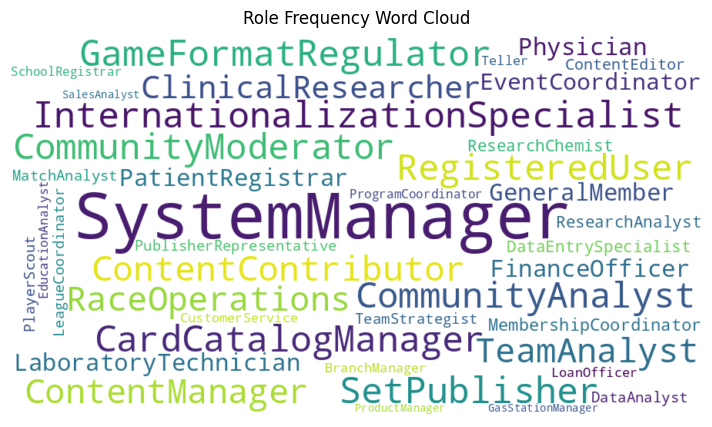

[INFO] Role distribution computed: top roles [{'role': 'SystemManager', 'count': 1534}, {'role': 'SetPublisher', 'count': 191}, {'role': 'InternationalizationSpecialist', 'count': 191}, {'role': 'CardCatalogManager', 'count': 191}, {'role': 'GameFormatRegulator', 'count': 191}, {'role': 'CommunityAnalyst', 'count': 186}, {'role': 'RegisteredUser', 'count': 186}, {'role': 'CommunityModerator', 'count': 186}, {'role': 'ContentContributor', 'count': 186}, {'role': 'RaceOperations', 'count': 174}]
[INFO] Permission breakdown: [{'permission': 'allowed', 'count': 3857}, {'permission': 'denied', 'count': 3212}]
[INFO] Summary metrics: {'Total unique roles': 40.0, 'Total role-conditioned examples': 7069.0, 'Allowed ratio': 0.5456}
[INFO] Permission breakdown: [{'permission': 'allowed', 'count': 3857}, {'permission': 'denied', 'count': 3212}]
[INFO] Summary metrics: {'Total unique roles': 40.0, 'Total role-conditioned examples': 7069.0, 'Allowed ratio': 0.5456}


In [10]:
if dataset_output:
    dataset_df = pd.DataFrame(dataset_output)
    role_counts = dataset_df["role"].value_counts().rename_axis("role").reset_index(name="count")
    permission_counts = (
        dataset_df["metadata"].apply(lambda m: m.get("permission", "unknown"))
        .value_counts()
        .rename_axis("permission")
        .reset_index(name="count")
    )
    permission_map = permission_counts.set_index("permission")["count"].to_dict() if not permission_counts.empty else {}
    total_examples = int(role_counts["count"].sum()) if not role_counts.empty else 0
    summary_metrics = pd.Series({
        "Total unique roles": role_counts.shape[0],
        "Total role-conditioned examples": total_examples,
        "Allowed ratio": round(permission_map.get("allowed", 0) / total_examples, 4) if total_examples else 0.0,
    })
    display(role_counts.head(15))
    display(permission_counts)
    display(summary_metrics.to_frame(name="value"))

    if 'WordCloud' in globals() and WordCloud is not None:
        wordcloud_text = {row.role: row.count for row in role_counts.itertuples()}
        if wordcloud_text:
            wc = WordCloud(width=900, height=500, background_color="white")
            wc.generate_from_frequencies(wordcloud_text)
            plt.figure(figsize=(10, 5))
            plt.imshow(wc, interpolation="bilinear")
            plt.axis("off")
            plt.title("Role Frequency Word Cloud")
            plt.show()
        else:
            print("Insufficient role data for word cloud generation.")

    logger.info("Role distribution computed: top roles %s", role_counts.head(10).to_dict("records"))
    logger.info("Permission breakdown: %s", permission_counts.to_dict("records"))
    logger.info("Summary metrics: %s", summary_metrics.to_dict())
else:
    print("Role distribution metrics are unavailable because dataset_output is empty.")

In [11]:
saved_dataset_path = None
if dataset_output:
    save_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    saved_dataset_path = role_sql_generator.save_bird_dataset(dataset_output, timestamp=save_timestamp)
    print(f"Dataset saved to {saved_dataset_path}")
    logger.info("Dataset saved to %s", saved_dataset_path)
else:
    print("Dataset is empty; nothing to save.")

[INFO] Bird dataset saved to: /home/feiy/Role-SQL-benchmark/outputs/role_sql_dataset_bird_dev_20250929_210750.json
[INFO] File size: 53,078,364 bytes
[INFO] Dataset saved to /home/feiy/Role-SQL-benchmark/outputs/role_sql_dataset_bird_dev_20250929_210750.json
[INFO] File size: 53,078,364 bytes
[INFO] Dataset saved to /home/feiy/Role-SQL-benchmark/outputs/role_sql_dataset_bird_dev_20250929_210750.json


Dataset saved to /home/feiy/Role-SQL-benchmark/outputs/role_sql_dataset_bird_dev_20250929_210750.json
